In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
#from imblearn.pipeline import make_pipeline
#from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_recall_curve, precision_recall_fscore_support, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from joblib import dump
import numpy as np
import matplotlib.pyplot as plt
#from imblearn.under_sampling import RandomUnderSampler
import os
from osgeo import gdal
import time
import functools
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
def parse_data(file_path):
    df = pd.read_csv(file_path, delimiter=';', index_col=False)
    #print("Original dataframe", df.head())
    print("Original dataframe shape", df.shape)
    #print all column names
    print("Column names", df.columns)
    # print all the nan values in the column nbr
    print("Nan values in the column nbr", df['NBR'].isna().sum())
    # Count unique numerical IDs where 'NBR' is NaN
    if 'numerical_id' in df.columns:
        unique_ids_with_nan = df.loc[df['NBR'].isna(), 'numerical_id'].nunique()
        print("Unique numerical IDs with NaN values in 'NBR':", unique_ids_with_nan)
    else:
        print("Column 'numerical_id' not found in the dataset!")
    print("Percentage of NaN values in 'NBR':", df['NBR'].isna().sum()/df.shape[0])
    print("Number of unique numerical IDs:", df['numerical_id'].nunique())
    print("percentage of unique numerical IDs with nan values in 'NBR':", unique_ids_with_nan/df['numerical_id'].nunique())
    return df

file_path = "/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/clear_forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed4_calibration.csv"
#file_path = '/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed2_calibration.csv'
df = parse_data(file_path)

Original dataframe shape (567084, 26)
Column names Index(['fid', 'country', 'plotid', 'year', 'class_level1', 'class_level2',
       'new_class2', 'new_disturblabel', 'uniqueid', 'numerical_id', 'x', 'y',
       'Tile_ID', 'merged_id', 'BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2', 'NBR',
       'NDVI', 'TCB', 'TCG', 'TCW', 'DIn'],
      dtype='object')
Nan values in the column nbr 37736
Unique numerical IDs with NaN values in 'NBR': 10691
Percentage of NaN values in 'NBR': 0.06654393352660276
Number of unique numerical IDs: 17069
percentage of unique numerical IDs with nan values in 'NBR': 0.6263401488077802


In [3]:
def encoding_disturbances(df):

    #df['class'] = df['class_level2'].apply(lambda x: 1 if x == 'disturbance' else 0)
    df['class'] = df['new_class2']


    return df

df = encoding_disturbances(df)
print("Shape after encoding disturbances", df.shape)
#print(df.head)

Shape after encoding disturbances (567084, 27)


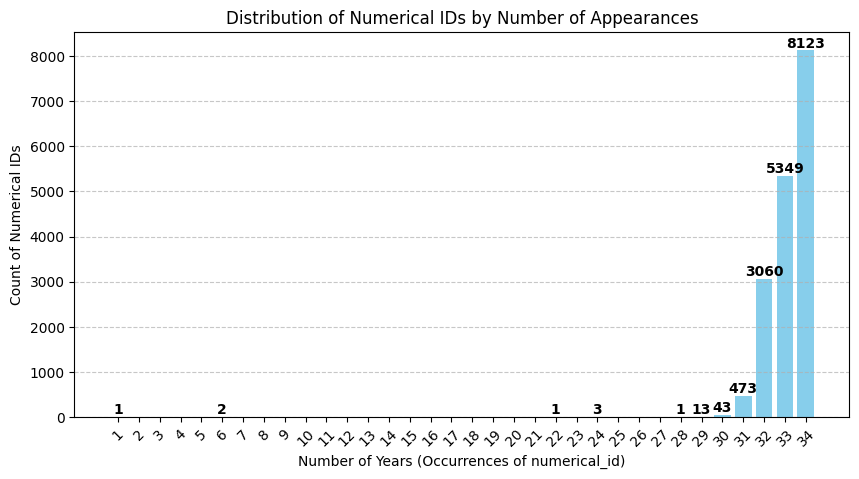

In [4]:
# Count occurrences of each numerical_id
id_counts = df['numerical_id'].value_counts()

# Count how many numerical_id's appear a certain number of times
count_distribution = id_counts.value_counts().sort_index()

# Filter only counts from 1 to 34
count_distribution = count_distribution[count_distribution.index]

# Plot bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(count_distribution.index, count_distribution.values, color='skyblue')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and title
plt.xlabel('Number of Years (Occurrences of numerical_id)')
plt.ylabel('Count of Numerical IDs')
plt.title('Distribution of Numerical IDs by Number of Appearances')
plt.xticks(range(1, 35), rotation=45)  # Show all years from 1 to 34
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [5]:
def drop_columns(df):
    df = df[['year', 'numerical_id', 'class', 'NDVI', 'NBR']]
    return df 

df = drop_columns(df)
print("Shape after dropping columns", df.shape)
print(df.head)

Shape after dropping columns (567084, 5)
<bound method NDFrame.head of         year  numerical_id  class      NDVI       NBR
0       1985             1      0  0.903261  0.691500
1       1986             1      0  0.846658  0.697250
2       1987             1      0  0.884108  0.714342
3       1988             1      0  0.862136  0.678677
4       1989             1      0  0.855061  0.706518
...      ...           ...    ...       ...       ...
567079  2014         19818      0  0.845379  0.790024
567080  2015         19818      0  0.789429  0.693477
567081  2016         19818      0       NaN       NaN
567082  2017         19818      0       NaN       NaN
567083  2018         19818      0  0.825513  0.720802

[567084 rows x 5 columns]>


In [6]:
def clear_folder(folder_path):
    """Remove all files inside the folder but keep the folder itself."""
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):
            os.remove(file_path)  # Remove only files, not the folder itself
    return 0

In [ ]:
def sort_by_year(df, time_column, id_column, file_name):
    # Convert the time_column to integers (if it's not already)
    df[time_column] = df[time_column].astype(int)

    # Sort the DataFrame by 'id_column' first and then 'time_column'
    df_sorted = df.sort_values(by=[id_column, time_column])  

    # Save the sorted DataFrame to a CSV file
    df_sorted.to_csv(file_name, index=False)  # `index=False` prevents writing row numbers
    
    return df_sorted

# Example usage
df_s = sort_by_year(df, time_column="year", id_column="numerical_id", file_name="sorted_data.csv")
print(df_s)

        year  numerical_id  class      NDVI       NBR
0       1985             1      0  0.903261  0.691500
1       1986             1      0  0.846658  0.697250
2       1987             1      0  0.884108  0.714342
3       1988             1      0  0.862136  0.678677
4       1989             1      0  0.855061  0.706518
...      ...           ...    ...       ...       ...
566377  2014         20084      0  0.701239  0.707365
566378  2015         20084      0       NaN       NaN
566379  2016         20084      0  0.718589  0.636226
566380  2017         20084      0  0.441148  0.570217
566381  2018         20084      0  0.781750  0.632764

[567084 rows x 5 columns]


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def plot_time_series(grouped, output_folder, time_column, value_columns, id_column):
    """
    Plots time series for each numerical_id with multiple value columns, 
    highlights the years when class == 1, and optionally shows interpolated values.

    Parameters:
    df (DataFrame): Input dataset.
    output_folder (str): Folder to save the plots.
    time_column (str): Column representing time (e.g., 'year').
    value_columns (list): List of value columns to plot (e.g., ['NBR', 'NDVI']).
    id_column (str): Column representing unique IDs (e.g., 'numerical_id').
    """
    
    # Debugging: Print current directory and output folder path
    print("Current working directory:", os.getcwd())
    print("Output folder path:", output_folder)
    
    # Make sure we are using an absolute path
    output_folder = os.path.abspath(output_folder)
    print("Resolved output folder:", output_folder)
    
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Clean up old plots (if necessary)
    for file in os.listdir(output_folder):
        file_path = os.path.join(output_folder, file)
        if os.path.isfile(file_path):
            os.remove(file_path)  # Remove each file
    
    # Use seaborn style defaults
    sns.set_theme(rc={'figure.figsize': (11, 4)})

    # Iterate over each group and plot the time series
    for num_id, group in grouped:
        plt.figure(figsize=(10, 5))

        # Plot each value column with a different color
        for col in value_columns:
            plt.plot(group[time_column], group[col], marker='o', linestyle='-', label=col)

        # Highlight the years where class == 1 (red dots) - disturbance
        class_1_years = group[group['class'] == 1]
        plt.scatter(class_1_years[time_column], class_1_years[value_columns[0]], 
                    color='red', label='Disturbance', zorder=5)

        # If 'interpolated' column exists, mark interpolated values with green dots
        interpolated_years = None
        if 'interpolated' in group.columns:
            interpolated_years = group[group['interpolated']]
            plt.scatter(interpolated_years[time_column], interpolated_years[value_columns[0]],
                        color='black', marker='x', label='Interpolated', zorder=8, s=100)  

        # Set x-axis labels as years
        plt.xticks(group[time_column], labels=group[time_column].astype(str))
        plt.xlabel('Year')
        plt.ylabel('Value') 
        plt.title(f'Time Series for ID: {num_id}')
        plt.legend()
        plt.grid()

        # Ensure x-axis shows only whole years
        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        # Determine the prefix for the plot name based on disturbance or interpolation
        plot_prefix = ""
        
        # Check if there is a disturbance (class == 1)
        if not class_1_years.empty:
            plot_prefix += "D_"  # Add 'D' if disturbance is present
        
        # Check if there are interpolated values
        if interpolated_years is not None and not interpolated_years.empty:
            plot_prefix += "I_"  # Add 'I' if interpolated values are present

        # Save the plot with the appropriate name
        plot_filename = f"{plot_prefix}{num_id}.png"
        plot_path = os.path.join(output_folder, plot_filename)
        plt.savefig(plot_path)
        plt.close()  # Free memory

    print(f"Time series plots saved in: {output_folder}")

    return 0

# Example usage
#output_folder = "/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks/time_series_plots"
#plot_time_series(df, output_folder, time_column="year", value_columns=["NBR", "NDVI"], id_column="numerical_id")


In [29]:
# delete all time series where the length is under 30

def filter_numerical_ids(df, min_count=30):
    """
    Remove numerical_id entries that appear less than min_count times.
    """
    id_counts = df['numerical_id'].value_counts()
    
    # Get the IDs that meet the minimum count requirement
    valid_ids = id_counts[id_counts >= min_count].index

    # Filter the DataFrame
    filtered_df = df[df['numerical_id'].isin(valid_ids)]
    
    return filtered_df

# Apply filtering
df_filtered = filter_numerical_ids(df, min_count=30)

# Print the count after filtering
print(count_numerical_ids(df_filtered))

Number of numerical_id's that appear in less than 34 years: 8925
numerical_id
1        34
10796    34
10733    34
10734    34
10438    34
         ..
445      30
754      30
755      30
1336     30
19209    30
Name: count, Length: 17048, dtype: int64


In [30]:
# mark all all the nan values for later plotting
df_filtered['interpolated'] = df_filtered['NBR'].isna()

print(df_filtered.head())

   year  numerical_id  class      NDVI       NBR  interpolated
0  1985             1      0  0.903261  0.691500         False
1  1986             1      0  0.846658  0.697250         False
2  1987             1      0  0.884108  0.714342         False
3  1988             1      0  0.862136  0.678677         False
4  1989             1      0  0.855061  0.706518         False


/tmp/ipykernel_367637/2998175777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['interpolated'] = df_filtered['NBR'].isna()


In [31]:
# instead, apply linear interpolation now 

df_linear = df_filtered.interpolate()
print(df_linear)

        year  numerical_id  class      NDVI       NBR  interpolated
0       1985             1      0  0.903261  0.691500         False
1       1986             1      0  0.846658  0.697250         False
2       1987             1      0  0.884108  0.714342         False
3       1988             1      0  0.862136  0.678677         False
4       1989             1      0  0.855061  0.706518         False
...      ...           ...    ...       ...       ...           ...
567079  2014         19818      0  0.845379  0.790024         False
567080  2015         19818      0  0.789429  0.693477         False
567081  2016         19818      0  0.801457  0.702585          True
567082  2017         19818      0  0.813485  0.711694          True
567083  2018         19818      0  0.825513  0.720802         False

[566572 rows x 6 columns]


Current working directory: /home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks
Output folder path: landsat_disturbance_detection/1D_U_Net/clean_notebooks/linear_interpolation
Resolved output folder: /home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks/landsat_disturbance_detection/1D_U_Net/clean_notebooks/linear_interpolation


KeyboardInterrupt: 

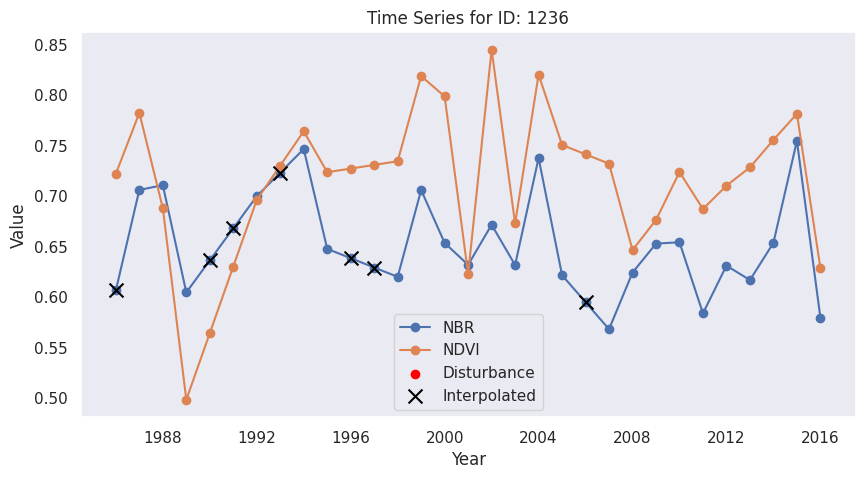

In [12]:
output_folder = "landsat_disturbance_detection/1D_U_Net/clean_notebooks/linear_interpolation"
plot_time_series(df_linear, output_folder, time_column="year", value_columns=["NBR", "NDVI"], id_column="numerical_id")